# 04 — Inspecting Result Objects

**Goal:** Know exactly what lives inside the object returned by `solver.fit()` and how to get it out.

Every `fit()` call returns a *result object* — a thin container that holds the ATT estimate, the fitted counterfactual panel, diagnostics, and estimator-specific internals (weights, fixed effects, factor matrices, etc.).

| Section | What you will learn |
|:---|:---|
| **1 — Setup** | Generate a synthetic panel with a known true ATT (Block treatment). |
| **2 — `summary()`** | Read the formatted diagnostics table for each estimator. |
| **3 — Plot** | Visualise actual vs. counterfactual with `plot_actual_vs_counterfactual()`. |
| **4 — Common attributes** | Access `tau`, `baseline`, `O`, `Z`, `residuals`, diagnostics directly. |
| **5 — Estimator-specific attributes** | DID fixed effects, SDID weights, MC-NNM low-rank M, OLS SC donor weights, DC-PR standard errors. |

We use **synthetic data throughout** so the true ATT `tau_true` is always available for reference.

In [1]:
import numpy as np
import pandas as pd

from causaltensor.synthetic import generate
from causaltensor.cauest.DID import DIDPanelSolver
from causaltensor.cauest.SDID import SDIDPanelSolver
from causaltensor.cauest.MCNNM import MCNNMPanelSolver
from causaltensor.cauest.OLSSyntheticControl import OLSSCPanelSolver
from causaltensor.cauest.DebiasConvex import DCPanelSolver
from causaltensor.cauest import CovariancePCAPanelSolver
from causaltensor.cauest import RSCPanelSolver

---
## 1 — Setup: synthetic panel with a known ATT

We generate a **Block** treatment panel: a subset of units are treated from period `T0` onwards. The true ATT `tau_true` is injected into `O`, so we can check how close each estimator gets.

In [2]:
N, T = 30, 50
O, Z, tau_true = generate(
    N=N, T=T,
    rank=3,
    noise_scale=0.5,
    treatment_pattern="Block",
    treatment_level=0.3,
    seed=42,
)

print(f"Panel shape : {O.shape}  (units x time)")
print(f"Treated cells: {int(Z.sum())} / {N*T}")
print(f"True ATT (tau_true): {tau_true:.4f}")

Panel shape : (30, 50)  (units x time)
Treated cells: 32 / 1500
True ATT (tau_true): 0.2896


In [3]:
# Fit all seven estimators
res_did    = DIDPanelSolver(O, Z).fit()
res_sdid   = SDIDPanelSolver(O, Z).fit()
res_mcnnm  = MCNNMPanelSolver(O, Z).fit()
res_sc     = OLSSCPanelSolver(O, Z).fit()
res_dc     = DCPanelSolver(O, Z).fit()
res_covpca = CovariancePCAPanelSolver(O, Z).fit()
res_rsc    = RSCPanelSolver(O, Z).fit()

results = {
    "DID":        res_did,
    "SDID":       res_sdid,
    "MC-NNM":     res_mcnnm,
    "OLS SC":     res_sc,
    "DC-PR":      res_dc,
    "CovPCA":     res_covpca,
    "RSC":        res_rsc,
}

print(f"{'Method':<12} {'tau_hat':>10} {'error':>10}")
print("-" * 34)
for name, res in results.items():
    tau_hat = float(np.mean(res.tau))
    err = abs(tau_hat - tau_true) / abs(tau_true)
    print(f"{name:<12} {tau_hat:>10.4f} {err:>9.1%}")
print(f"\ntau_true = {tau_true:.4f}")

Method          tau_hat      error
----------------------------------
DID              0.3223     11.3%
SDID             0.3846     32.8%
MC-NNM           0.3272     13.0%
OLS SC           0.2022     30.2%
DC-PR            0.0748     74.2%
CovPCA           0.0365     87.4%
RSC              0.2249     22.4%

tau_true = 0.2896


---
## 2 — `result.summary()`

`summary()` prints a formatted table with four sections:

| Section | Contents |
|:---|:---|
| **Panel info** | Shape, treated-cell share, treatment pattern (Block / Staggered / Non-monotone). |
| **ATT** | Point estimate; std dev and inference method if available. |
| **Fit diagnostics** | Untreated R², Control RMSE, Pre-exposure RMSE, RMSPE ratio. |
| **Model internals** | Estimator-specific: rank, FE ranges, weights summary, covariate coefs, factor shape. |

It returns `self`, so you can chain: `solver.fit().summary().plot_actual_vs_counterfactual(unit=0)`.

In [4]:
# DID: shows unit + time fixed effects
res_did.summary();

  DIDResult
  Panel                     : 30 units x 50 periods
  Treated cells             : 32 / 1500  (2.1%)
  Treated units             : 2
  Treatment pattern         : Block  (T0 = 34)
--------------------------------------------------------
  ATT (tau)                 : 0.322309

  --- Fit diagnostics ---
  Untreated R2              : 0.01415
  Control RMSE              : 1.3313
  Pre-exposure RMSE         : 1.34215  (1468 cells)
  RMSPE ratio               : 0.2401

  --- Model internals ---
  row_FE (unit)           : min=-0.2473  mean=-0.03148  max=0.2051
  col_FE (time)           : min=-0.2364  mean=-2.082e-18  max=0.3195


In [5]:
# SDID: shows donor unit weights and time weights
res_sdid.summary();

  SDIDResult
  Panel                     : 30 units x 50 periods
  Treated cells             : 32 / 1500  (2.1%)
  Treated units             : 2
  Treatment pattern         : Block  (T0 = 34)
--------------------------------------------------------
  ATT (tau)                 : 0.384587

  --- Fit diagnostics ---
  Untreated R2              : -0.2303
  Control RMSE              : 1.50392
  Pre-exposure RMSE         : 1.49934  (1468 cells)
  RMSPE ratio               : 0.2565

  --- Model internals ---
  unit_weights            : 30 nonzero  (top: unit 3, w=0.5)
    (full array)          : result.unit_weights
  time_weights            : 33 nonzero
    (full array)          : result.time_weights


In [6]:
# MC-NNM: shows rank of the recovered low-rank matrix
res_mcnnm.summary();

  MCNNMResult
  Panel                     : 30 units x 50 periods
  Treated cells             : 32 / 1500  (2.1%)
  Treated units             : 2
  Treatment pattern         : Block  (T0 = 34)
--------------------------------------------------------
  ATT (tau)                 : 0.327204

  --- Fit diagnostics ---
  Untreated R2              : 0.9085
  Control RMSE              : 0.403777
  Pre-exposure RMSE         : 0.408903  (1468 cells)
  RMSPE ratio               : 0.8002

  --- Model internals ---
  rank(M)                 : 14
  row_FE (unit)           : min=-0.2467  mean=-0.03093  max=0.2058
  col_FE (time)           : min=-0.2369  mean=-0.0006516  max=0.3189


In [7]:
# OLS SC: per-unit ATT, donor count
res_sc.summary();

  OLSSCResult
  Panel                     : 30 units x 50 periods
  Treated cells             : 32 / 1500  (2.1%)
  Treated units             : 2
  Treatment pattern         : Block  (T0 = 34)
--------------------------------------------------------
  ATT (tau)                 : 0.202209

  --- Fit diagnostics ---
  Untreated R2              : 0.9823
  Control RMSE              : 0
  Pre-exposure RMSE         : 0.179585  (1468 cells)
  RMSPE ratio               : 1.126

  --- Model internals ---
  n_treated_units         : 2
  n_donor_units           : 28
    (weights per unit)    : result.beta  (list of arrays)
    (unit indices)        : result.treatment_units, result.control_units

  per-unit ATT:
    unit 3     : tau=0.2243  (4 donors)
    unit 19    : tau=0.1801  (4 donors)


In [8]:
# DC-PR: reports sandwich SE alongside the ATT
res_dc.summary();
# Note: std_tau / inference_method appear in the ATT block when available

  DCResult
  Panel                     : 30 units x 50 periods
  Treated cells             : 32 / 1500  (2.1%)
  Treated units             : 2
  Treatment pattern         : Block  (T0 = 34)
--------------------------------------------------------
  ATT (tau)                 : 0.0747896
  Std dev (tau)             : 0.0496746
  Inference method          : sandwich SE

  --- Fit diagnostics ---
  Untreated R2              : 0.9977
  Control RMSE              : 0.0646977
  Pre-exposure RMSE         : 0.0643308  (1468 cells)
  RMSPE ratio               : 1.163

  --- Model internals ---
  rank(M)                 : 26


In [9]:
# CovPCA: shows number of factors and left-factor matrix shape
res_covpca.summary();

  CovariancePCAResult
  Panel                     : 30 units x 50 periods
  Treated cells             : 32 / 1500  (2.1%)
  Treated units             : 2
  Treatment pattern         : Block  (T0 = 34)
--------------------------------------------------------
  ATT (tau)                 : 0.0365257

  --- Fit diagnostics ---
  Untreated R2              : 0.917
  Control RMSE              : 0.394916
  Pre-exposure RMSE         : 0.389483  (1468 cells)
  RMSPE ratio               : 0.09378

  --- Model internals ---
  num_factors             : 7
  factor_matrix (U) shape : (30, 7)  (units x factors)


In [10]:
# RSC: lean summary — rank of the low-rank donor SVD is shown in model internals
res_rsc.summary();

  RSCResult
  Panel                     : 30 units x 50 periods
  Treated cells             : 32 / 1500  (2.1%)
  Treated units             : 2
  Treatment pattern         : Block  (T0 = 34)
--------------------------------------------------------
  ATT (tau)                 : 0.224859

  --- Fit diagnostics ---
  Untreated R2              : 0.8812
  Control RMSE              : 0.455889
  Pre-exposure RMSE         : 0.465866  (1468 cells)
  RMSPE ratio               : 0.4827

  --- Model internals ---
  rank(M)                 : 3


**Reading the diagnostics:**

* **Untreated R²** — how much variance in Z=0 cells the counterfactual explains. Close to 1.0 = good fit.
* **Control RMSE** — prediction error on pure control units (never treated) across all time periods. Lower = the model generalises well to unaffected units.
* **Pre-exposure RMSE** — prediction error on treated units *before* their treatment onset. If this is small, the counterfactual tracked the treated unit pre-treatment, making the post-treatment gap more credible.
* **RMSPE ratio** — `|ATT| / Pre-exposure RMSE`. A value >> 1 means the estimated effect is large relative to the in-sample fit noise (a common placebo-test signal).

---
## 3 — `result.plot_actual_vs_counterfactual(unit)`

Pass any row index. The plot shows:
* Solid blue line — actual outcome `O[unit, :]`
* Dashed orange line — fitted counterfactual `baseline[unit, :]`
* Green shading — treatment periods (Z = 1 for this unit)
* Green dashed vertical line at T0 with "Treatment" label
* Annotation box — unit ATT, pre-treatment RMSE, overall ATT

Use `unit_label` to add a human-readable name and `time_labels` for proper axis ticks.

In [11]:
# Pick a treated unit to plot
treated_units = np.where(np.any(Z > 0, axis=1))[0]
unit_to_plot  = int(treated_units[0])
print(f"Plotting unit {unit_to_plot} (treated)")

Plotting unit 3 (treated)


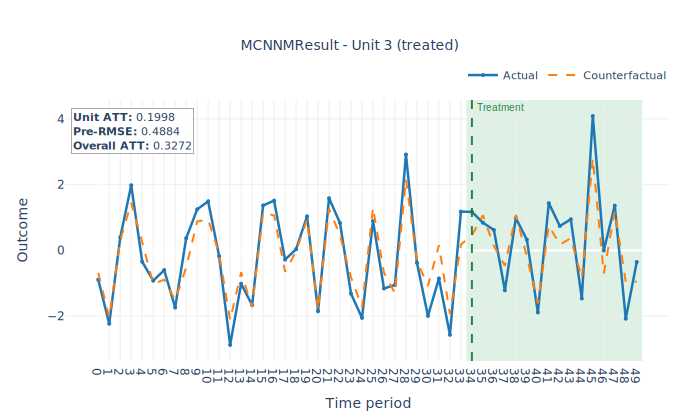

In [12]:
# MC-NNM — treated unit
res_mcnnm.plot_actual_vs_counterfactual(
    unit=unit_to_plot,
    unit_label=f"Unit {unit_to_plot} (treated)",
    time_labels=list(range(T)),
).show("svg")

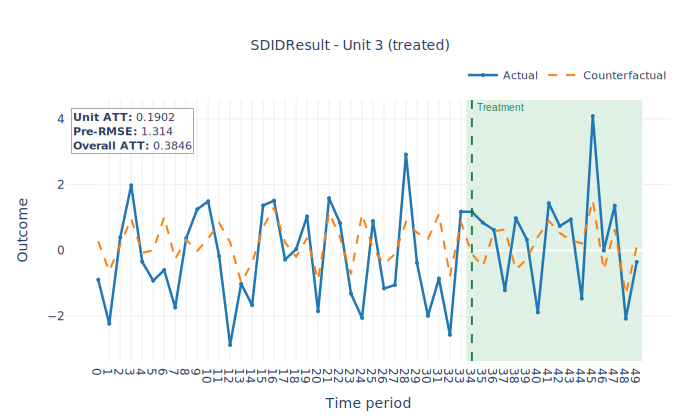

In [30]:
# SDID — same unit for comparison
res_sdid.plot_actual_vs_counterfactual(
    unit=unit_to_plot,
    unit_label=f"Unit {unit_to_plot} (treated)",
    time_labels=list(range(T)),
).show("svg")

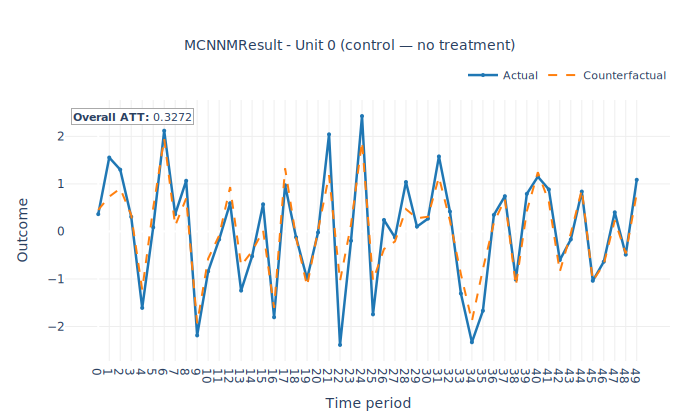

In [14]:
# Control unit — no treatment; counterfactual should track actual closely
control_units = np.where(~np.any(Z > 0, axis=1))[0]
unit_control  = int(control_units[0])

res_mcnnm.plot_actual_vs_counterfactual(
    unit=unit_control,
    unit_label=f"Unit {unit_control} (control — no treatment)",
    time_labels=list(range(T)),
).show("svg")

---
## 4 — Common attributes

All result objects expose these fields regardless of which estimator you used.

In [15]:
res = res_mcnnm  # use MC-NNM as the running example

# --- Core estimates ---
print("tau (ATT estimate):", res.tau)
print("tau_true           :", tau_true)
print("baseline shape     :", res.baseline.shape)  # fitted counterfactual (N, T)
print("O shape            :", res.O.shape)          # original outcomes
print("Z shape            :", res.Z.shape)          # treatment mask

tau (ATT estimate): 0.32720357405529876
tau_true           : 0.2896295285797089
baseline shape     : (30, 50)
O shape            : (30, 50)
Z shape            : (30, 50)


In [16]:
# --- Derived arrays (computed properties) ---
print("residuals shape    :", res.residuals.shape)     # O - baseline, all cells
print("effect_matrix shape:", res.effect_matrix.shape) # (O - baseline) * (Z > 0)

residuals shape    : (30, 50)
effect_matrix shape: (30, 50)


In [17]:
# --- Treatment pattern ---
print("z_pattern:", res.z_pattern)  # 'block', 'staggered', or 'non-monotone'

z_pattern: block


In [18]:
# --- Fit diagnostics ---
print(f"Untreated R²      : {res.untreated_r2:.4f}")
print(f"Control RMSE      : {res.control_rmse:.4f}")
print(f"Pre-exposure RMSE : {res.pre_exposure_rmse:.4f}")
print(f"RMSPE ratio       : {res.rmspe_ratio:.4f}")

Untreated R²      : 0.9085
Control RMSE      : 0.4038
Pre-exposure RMSE : 0.4089
RMSPE ratio       : 0.8002


In [19]:
# --- Diagnostic comparison across estimators ---
rows = []
for name, res in results.items():
    rows.append({
        "Method":          name,
        "tau_hat":         round(float(np.mean(res.tau)), 4),
        "Untreated R2":    round(res.untreated_r2, 4)          if res.untreated_r2 is not None else None,
        "Control RMSE":    round(res.control_rmse, 4)          if res.control_rmse is not None else None,
        "Pre-exp. RMSE":   round(res.pre_exposure_rmse, 4)     if res.pre_exposure_rmse is not None else None,
        "RMSPE ratio":     round(res.rmspe_ratio, 2)           if res.rmspe_ratio is not None else None,
    })

df_diag = pd.DataFrame(rows).set_index("Method")
print(f"True ATT: {tau_true:.4f}")
df_diag

True ATT: 0.2896


,tau_hat,Untreated R2,Control RMSE,Pre-exp. RMSE,RMSPE ratio
Method,,,,,
DID,0.3223,0.0141,1.3313,1.3421,0.24
SDID,0.3846,-0.2303,1.5039,1.4993,0.26
MC-NNM,0.3272,0.9085,0.4038,0.4089,0.80
OLS SC,0.2022,0.9823,0.0000,0.1796,1.13
DC-PR,0.0748,0.9977,0.0647,0.0643,1.16
CovPCA,0.0365,0.9170,0.3949,0.3895,0.09
RSC,0.2249,0.8812,0.4559,0.4659,0.48


---
## 5 — Estimator-specific attributes

### 5a — DID: unit and time fixed effects

In [20]:
print("Unit FE (row_fixed_effects) shape:", res_did.row_fixed_effects.shape)  # (N,)
print("Time FE (column_fixed_effects) shape:", res_did.column_fixed_effects.shape)  # (T,)
print()
print("First 5 unit FEs:", res_did.row_fixed_effects[:5].round(4))
print("First 5 time FEs:", res_did.column_fixed_effects[:5].round(4))
print()
print("Covariate coefs (beta):", res_did.beta)  # None when no X is passed

Unit FE (row_fixed_effects) shape: (30, 1)
Time FE (column_fixed_effects) shape: (50, 1)

First 5 unit FEs: [[ 0.0082]
 [ 0.2051]
 [-0.004 ]
 [-0.1748]
 [-0.1834]]
First 5 time FEs: [[-0.0692]
 [-0.0525]
 [ 0.1129]
 [ 0.2734]
 [-0.0012]]

Covariate coefs (beta): None


### 5b — SDID: donor unit weights and time weights

In [21]:
w = res_sdid.unit_weights   # shape (N,)
l = res_sdid.time_weights   # shape (T,)

print("unit_weights shape:", w.shape)
print("time_weights shape:", l.shape)
print()

# Top donor units by weight
nonzero_units = np.where(w > 1e-4)[0]
print(f"Nonzero unit weights: {len(nonzero_units)} units")
top5 = nonzero_units[np.argsort(w[nonzero_units])[::-1][:5]]
for i in top5:
    print(f"  unit {i:3d}  w = {w[i]:.4f}")

unit_weights shape: (30,)
time_weights shape: (50,)

Nonzero unit weights: 30 units
  unit   3  w = 0.5000
  unit  19  w = 0.5000
  unit  21  w = 0.0579
  unit  13  w = 0.0569
  unit  26  w = 0.0520


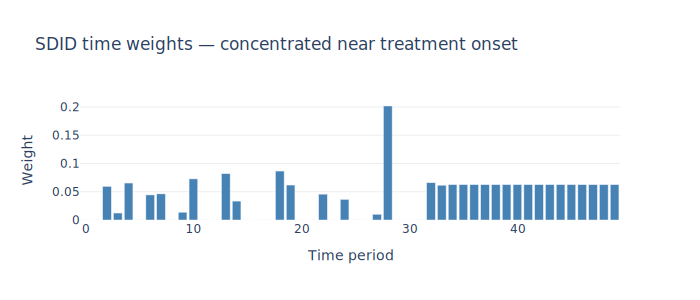

In [22]:
import plotly.graph_objects as go

fig = go.Figure()
fig.add_trace(go.Bar(
    x=list(range(T)), y=l,
    marker_color="steelblue",
    name="time weight",
))
fig.update_layout(
    title="SDID time weights — concentrated near treatment onset",
    xaxis_title="Time period",
    yaxis_title="Weight",
    height=300,
    plot_bgcolor="white",
    paper_bgcolor="white",
)
fig.update_yaxes(showgrid=True, gridcolor="#eeeeee")
fig.show("svg")

### 5c — MC-NNM: low-rank component and fixed effects

In [23]:
print("M (low-rank component) shape  :", res_mcnnm.M.shape)       # (N, T)
print("baseline (M + FEs) shape      :", res_mcnnm.baseline.shape) # (N, T)
print("rank(M)                        :", np.linalg.matrix_rank(res_mcnnm.M))
print()
# FE vectors may be stored as (N, 1) / (T, 1) column vectors — ravel to 1D
row_fe = res_mcnnm.row_fixed_effects.ravel()    # (N,)
col_fe = res_mcnnm.column_fixed_effects.ravel() # (T,)
print("row_fixed_effects  shape:", row_fe.shape)
print("column_fixed_effects shape:", col_fe.shape)
print()
# baseline = M + broadcast row_FE + broadcast col_FE
recon = res_mcnnm.M + row_fe[:, None] + col_fe[None, :]
print("Max diff |baseline - (M + row_FE + col_FE)|:",
      np.max(np.abs(res_mcnnm.baseline - recon)).round(8))

M (low-rank component) shape  : (30, 50)
baseline (M + FEs) shape      : (30, 50)
rank(M)                        : 14

row_fixed_effects  shape: (30,)
column_fixed_effects shape: (50,)

Max diff |baseline - (M + row_FE + col_FE)|: 0.0


### 5d — OLS Synthetic Control: donor weights and per-unit ATT

In [24]:
print("control_units (donor indices) :", res_sc.control_units[:5], "...")
print("treatment_units               :", res_sc.treatment_units)
print()
print("Number of donor weight vectors:", len(res_sc.beta))  # one per treated unit
print("Weight vector for first treated unit (top 5):")
w_first = res_sc.beta[0]
top5_idx = np.argsort(w_first)[::-1][:5]
for k in top5_idx:
    print(f"  donor {res_sc.control_units[k]:3d}  w = {w_first[k]:.4f}")

control_units (donor indices) : [0, 1, 2, 4, 5] ...
treatment_units               : [3, 19]

Number of donor weight vectors: 2
Weight vector for first treated unit (top 5):
  donor  11  w = 0.4996
  donor  24  w = 0.2330
  donor   7  w = 0.1637
  donor  21  w = 0.1037
  donor  13  w = 0.0000


In [25]:
# Per-unit treatment effects
print("individual_te — [unit_idx, tau_hat]:")
for row in res_sc.individual_te:
    print(f"  unit {row[0]:3d}  tau_hat = {row[1]:.4f}")

individual_te — [unit_idx, tau_hat]:
  unit   3  tau_hat = 0.2243
  unit  19  tau_hat = 0.1801


### 5e — DC-PR: standard error from sandwich estimator

In [26]:
print("tau (ATT)       :", round(float(res_dc.tau), 4))
print("std / std_tau   :", round(float(res_dc.std), 4))   # both attributes work
print("inference_method:", res_dc.inference_method)       # 'sandwich SE'
print()
# 95% CI under normality
tau_dc  = float(res_dc.tau)
std_dc  = float(res_dc.std)
ci_lo   = tau_dc - 1.96 * std_dc
ci_hi   = tau_dc + 1.96 * std_dc
print(f"95% CI (normal approx): [{ci_lo:.4f}, {ci_hi:.4f}]")
print(f"True ATT in CI: {ci_lo:.4f} <= {tau_true:.4f} <= {ci_hi:.4f} — "
      f"{'yes' if ci_lo <= tau_true <= ci_hi else 'no'}")

tau (ATT)       : 0.0748
std / std_tau   : 0.0497
inference_method: sandwich SE

95% CI (normal approx): [-0.0226, 0.1722]
True ATT in CI: -0.0226 <= 0.2896 <= 0.1722 — no


### 5f — Covariance PCA: left factor matrix

In [27]:
print("U (left factor matrix) shape:", res_covpca.U.shape)   # (N, r)
print("Number of factors r         :", res_covpca.U.shape[1])
print("baseline shape              :", res_covpca.baseline.shape)
print("rank(baseline)              :", np.linalg.matrix_rank(res_covpca.baseline))

U (left factor matrix) shape: (30, 7)
Number of factors r         : 7
baseline shape              : (30, 50)
rank(baseline)              : 7


### 5g — RSC: low-rank donor SVD

In [28]:
# RSC exposes only the core attributes shared by all result objects.
# The SVD rank used internally is visible in summary() under "Model internals".
print("baseline (low-rank counterfactual) shape:", res_rsc.baseline.shape)
print("M shape (alias for baseline)            :", res_rsc.M.shape)
print("rank(baseline)                          :", np.linalg.matrix_rank(res_rsc.baseline))
print("tau                                     :", round(float(res_rsc.tau), 4))

baseline (low-rank counterfactual) shape: (30, 50)
M shape (alias for baseline)            : (30, 50)
rank(baseline)                          : 3
tau                                     : 0.2249


---
## Summary

| What you want | How to get it |
|:---|:---|
| ATT estimate | `result.tau` |
| Fitted counterfactual | `result.baseline` (all methods) or `result.M` |
| Treatment effect on treated cells | `result.effect_matrix` |
| Formatted diagnostics table | `result.summary()` |
| Actual vs. counterfactual chart | `result.plot_actual_vs_counterfactual(unit)` |
| Model fit quality | `result.untreated_r2`, `result.control_rmse`, `result.pre_exposure_rmse` |
| Treatment pattern | `result.z_pattern` |
| **DID** — unit / time fixed effects | `result.row_fixed_effects`, `result.column_fixed_effects` |
| **DID** — covariate coefs | `result.beta` |
| **SDID** — donor / time weights | `result.unit_weights`, `result.time_weights` |
| **MC-NNM** — low-rank component | `result.M`, `result.row_fixed_effects`, `result.column_fixed_effects` |
| **OLS SC** — donor weights | `result.beta[i]` for the i-th treated unit |
| **OLS SC** — per-unit ATT | `result.individual_te` |
| **OLS SC** — donor / treated indices | `result.control_units`, `result.treatment_units` |
| **DC-PR** — standard error | `result.std` (also `result.std_tau`) |
| **CovPCA** — left factor matrix | `result.U`  (N × r) |
| **RSC** — counterfactual | `result.baseline` / `result.M` |

For the complete attribute reference see the [API docs](../../docs/api.rst).